<a href="https://colab.research.google.com/github/dmburt/BayesianInference/blob/main/Bistro_Examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade git+https://github.com/dmburt/bistro.git watermark

  Cloning https://github.com/dmburt/bistro.git to /tmp/pip-req-build-vtm4f37j
  Running command git clone --filter=blob:none --quiet https://github.com/dmburt/bistro.git /tmp/pip-req-build-vtm4f37j
  Resolved https://github.com/dmburt/bistro.git to commit 97aea1d90ae8a49877b6623e61ade09e1575b3c3
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.2/109.2 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.4 MB/s eta 0:00:00
  Created wheel for bistro: filename=bistro-1.0.20221230-py3-none-any.whl size=10358 sha256=8bdde6c3d84bf2e08b8c753e5714c040a3cdca58a288ee083f0dc4778c8a55e0
  Stored in directory: /tmp/pip-ephem-wheel-cache-c93g3yy9/wheels/f5/1c/8e/423a9a63a2779af19bc61f65cd11013ee00ce04324f41a5fba
Successfully built bistro


In [2]:
import numpy as np
import pandas as pd
from bistro import BModel

from matplotlib import pyplot as plt
from matplotlib import rcParams


from IPython import display
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


def set_style():
    font = {'family' : 'Liberation Sans',
            #'size'   : 16
           }
    math_fontfamily = {'family' : 'Liberation Sans',
                      }
    plt.style.use(['seaborn-v0_8-whitegrid', 'seaborn-v0_8-paper'])

set_style()


rcParams["mathtext.fontset"] = 'custom'
rcParams["mathtext.rm"] = 'Liberation Sans'
rcParams["mathtext.it"] = 'Liberation Sans'
rcParams["mathtext.sf"] = 'Liberation Sans'
rcParams['font.cursive'] = 'Liberation Sans'

import watermark

%matplotlib inline
%config InlineBackend.figure_format='retina'


## Make test data

The synthetic dataset includes:

TREAT: A binary indicator (1 = treatment, 0 = control)

POST: A binary indicator for the post-intervention period

Y: The outcome variable (average ED visits per person per month over the period)

age: An additional covariate (for optional matching)

In [3]:
# Set seed for reproducibility
np.random.seed(42)

# Number of observations per group/time period
n_per_group = 100

# --- Control Group ---
# Pre-intervention data (baseline ED visits ~10)
control_pre = pd.DataFrame({
    'TREAT': 0,
    'POST': 0,
    'Y': np.random.normal(loc=10, scale=2, size=n_per_group)
})
# Post-intervention data (small natural decline, e.g., ED visits ~9)
control_post = pd.DataFrame({
    'TREAT': 0,
    'POST': 1,
    'Y': np.random.normal(loc=9, scale=2, size=n_per_group)
})

# --- Treatment Group ---
# Pre-intervention data (similar baseline)
treat_pre = pd.DataFrame({
    'TREAT': 1,
    'POST': 0,
    'Y': np.random.normal(loc=10, scale=2, size=n_per_group)
})
# Post-intervention data (larger reduction due to provider education, e.g., ED visits ~7)
treat_post = pd.DataFrame({
    'TREAT': 1,
    'POST': 1,
    'Y': np.random.normal(loc=7, scale=2, size=n_per_group)
})

# Combine all data into a single DataFrame
df = pd.concat([control_pre, control_post, treat_pre, treat_post], ignore_index=True)

# (Optional) Add a covariate (e.g., age) to later demonstrate matching
df['age'] = np.random.randint(30, 70, size=len(df))

# Display the first few rows of the dataset
df.head()

,TREAT,POST,Y,age
0,0,0,10.993428,64
1,0,0,9.723471,30
2,0,0,11.295377,50
3,0,0,13.046060,35
4,0,0,9.531693,57


## 2. Fitting the Difference-in-Differences Model

Next, we create a BModel instance from bistro. We split the data into treatment and control groups and then fit a DiD regression model using a patsy-style formula. In our formula:

TREAT captures the difference between groups,

POST captures the time effect, and

TREAT * POST represents the interaction term—the DiD effect.

In [4]:
# Separate the data by treatment group
df_treat = df[df['TREAT'] == 1]
df_control = df[df['TREAT'] == 0]

# Create a BModel instance, specifying the treatment variable
model = BModel(data_treat=df_treat, data_control=df_control, treat_var='TREAT')

# Fit the difference-in-differences regression model
model.fit(reg_formula='Y ~ TREAT + POST + TREAT*POST')

Output()

## 3. Model Diagnostics: Trace Plots

It is important to check the convergence of the Bayesian model’s posterior distributions. The trace plot below shows the sampling behavior for each parameter.

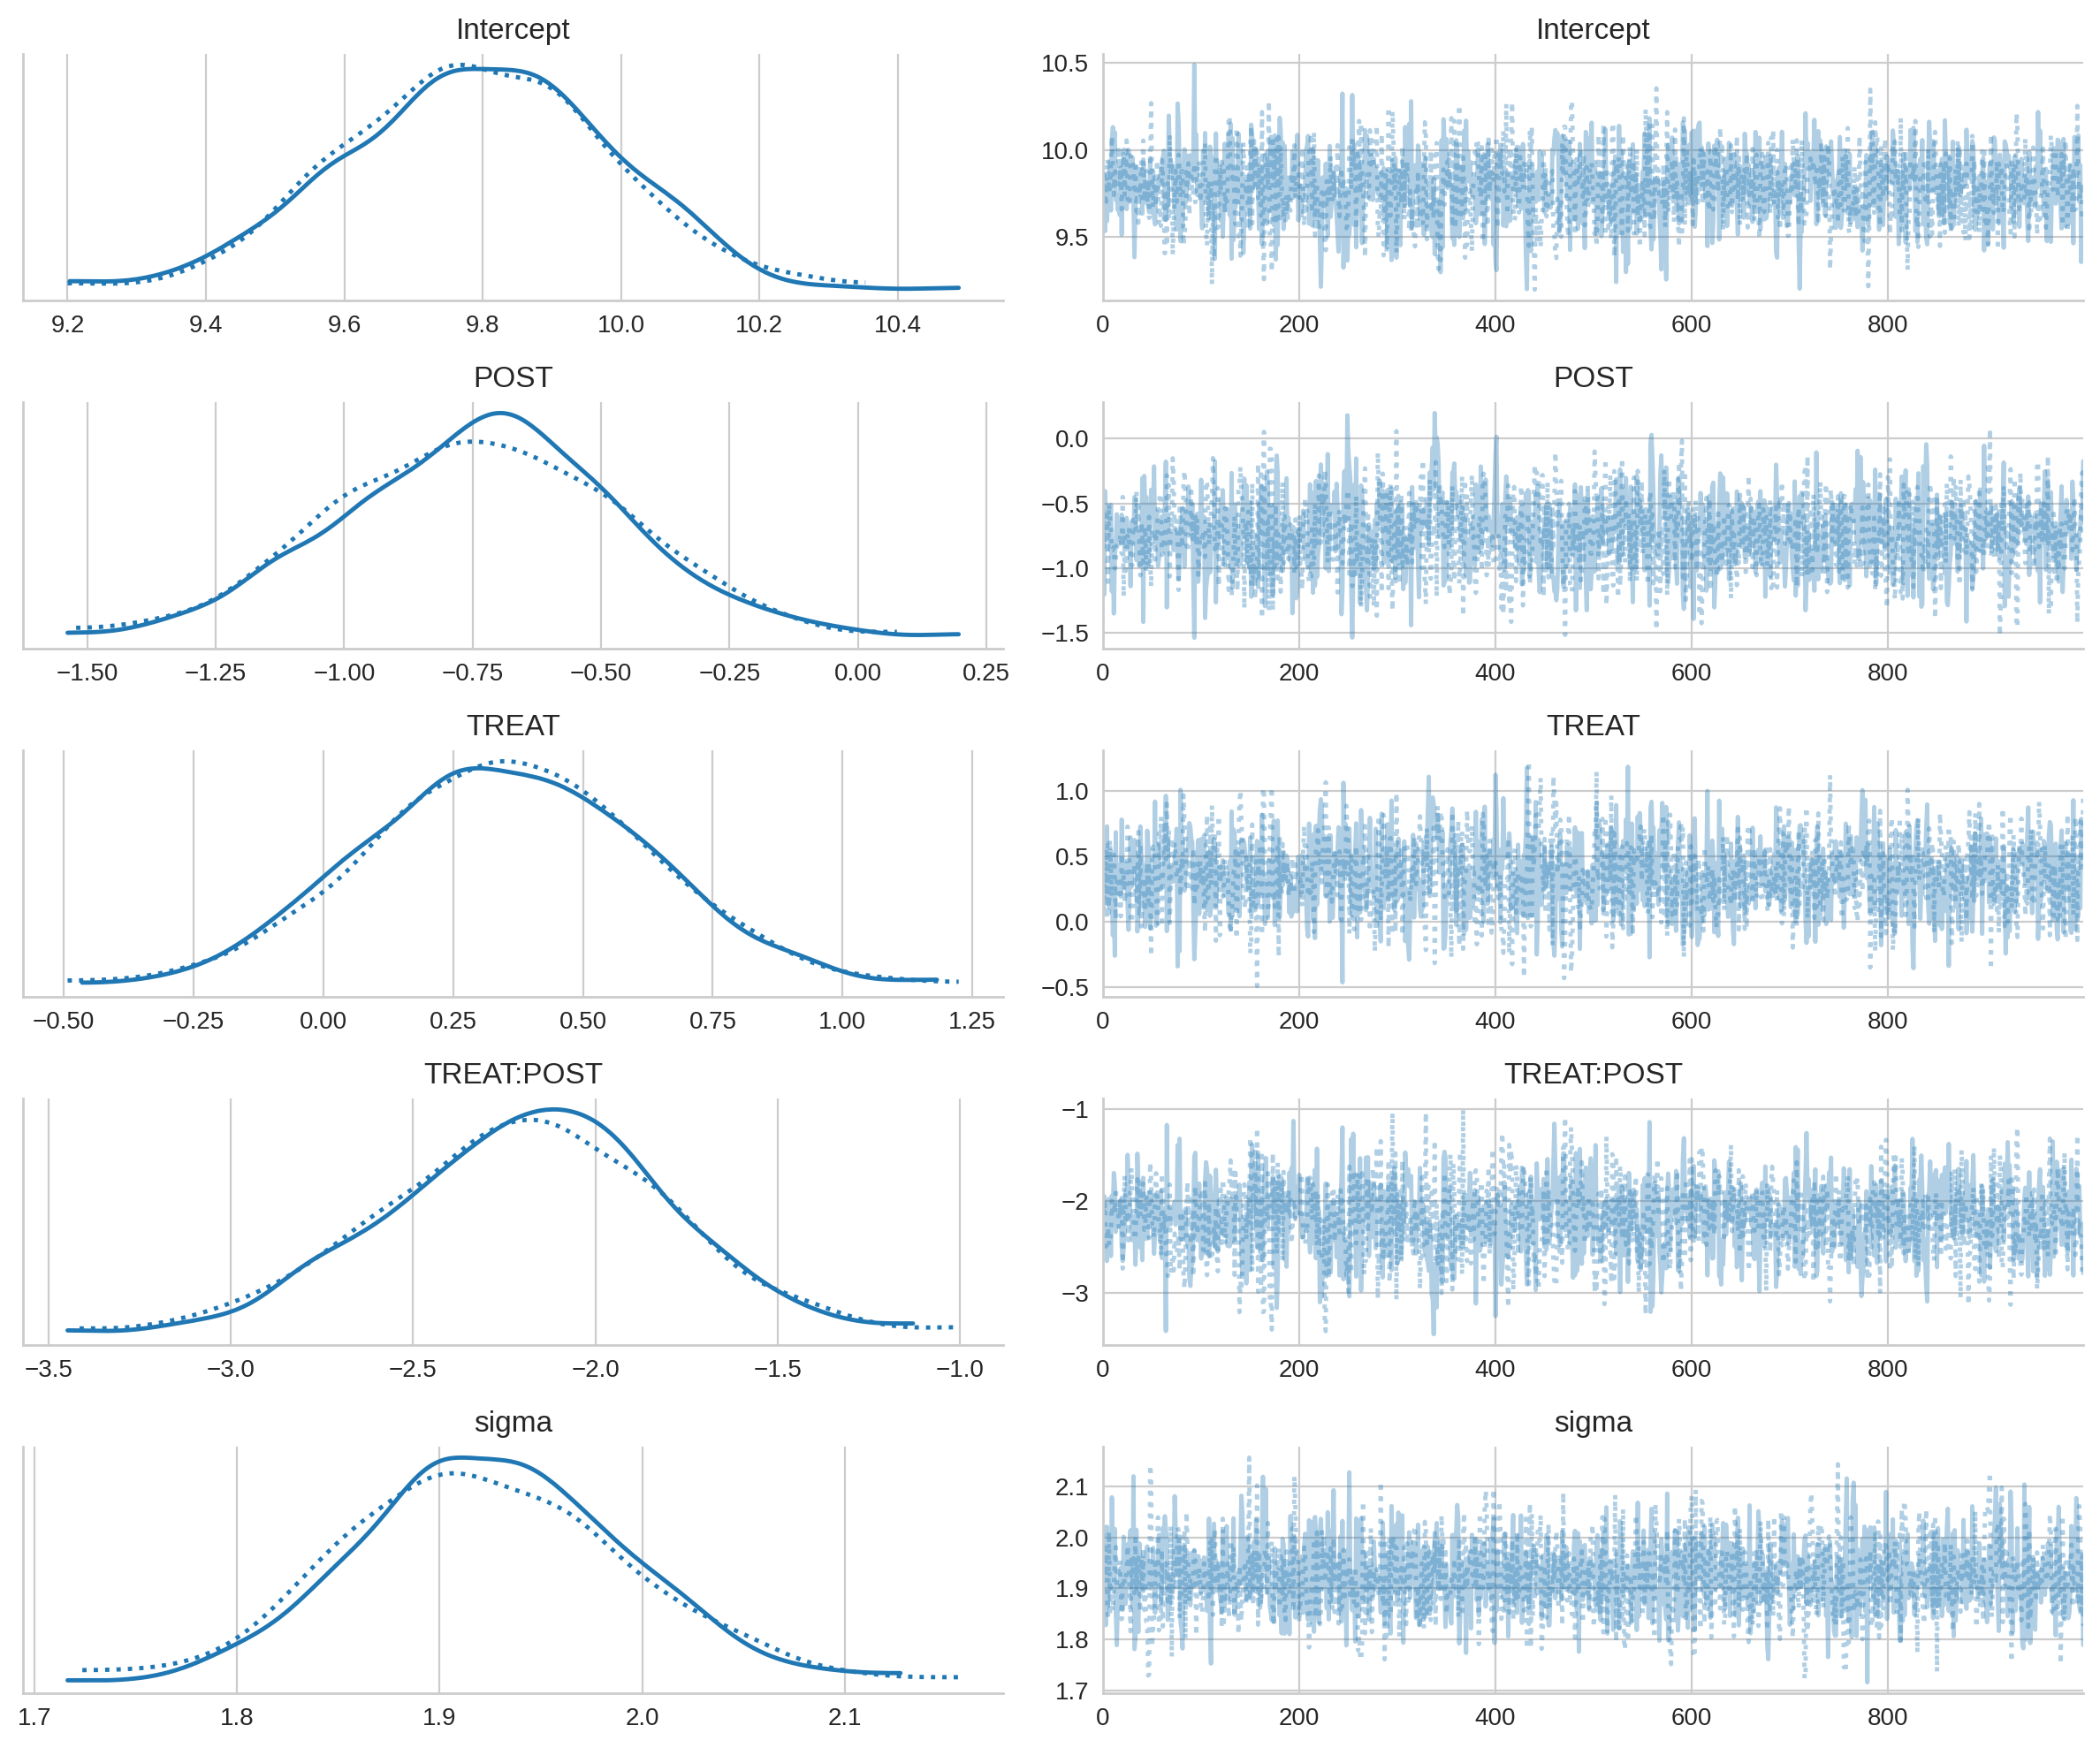

In [5]:
model.plot_trace()

## 4. Visualizing the DiD Effects

This cell visualizes the estimated regression lines for both the treatment (factual and counterfactual) and control groups. On the left, you’ll see the fitted trajectories, and on the right, the highest-density interval (HDI) for the DiD effect (the interaction term). The plotted DiD estimate quantifies the impact of the intervention.

In the plot on the left:

The treatment factual line represents the observed outcomes in the treatment group post-intervention.

The treatment counterfactual line shows the estimated trajectory if the intervention had not occurred.

The control line represents the control group’s outcome over time.

The right-hand plot displays the highest-density interval for the interaction (DiD) term. If the interval does not include zero, it suggests a statistically meaningful effect of the intervention. In our simulation, you should see a pronounced decrease in ED visits among the treatment group following the intervention compared to the control group.

This example demonstrates how Bayesian regression methods can be presented in a framework that is accessible to those with a frequentist background.

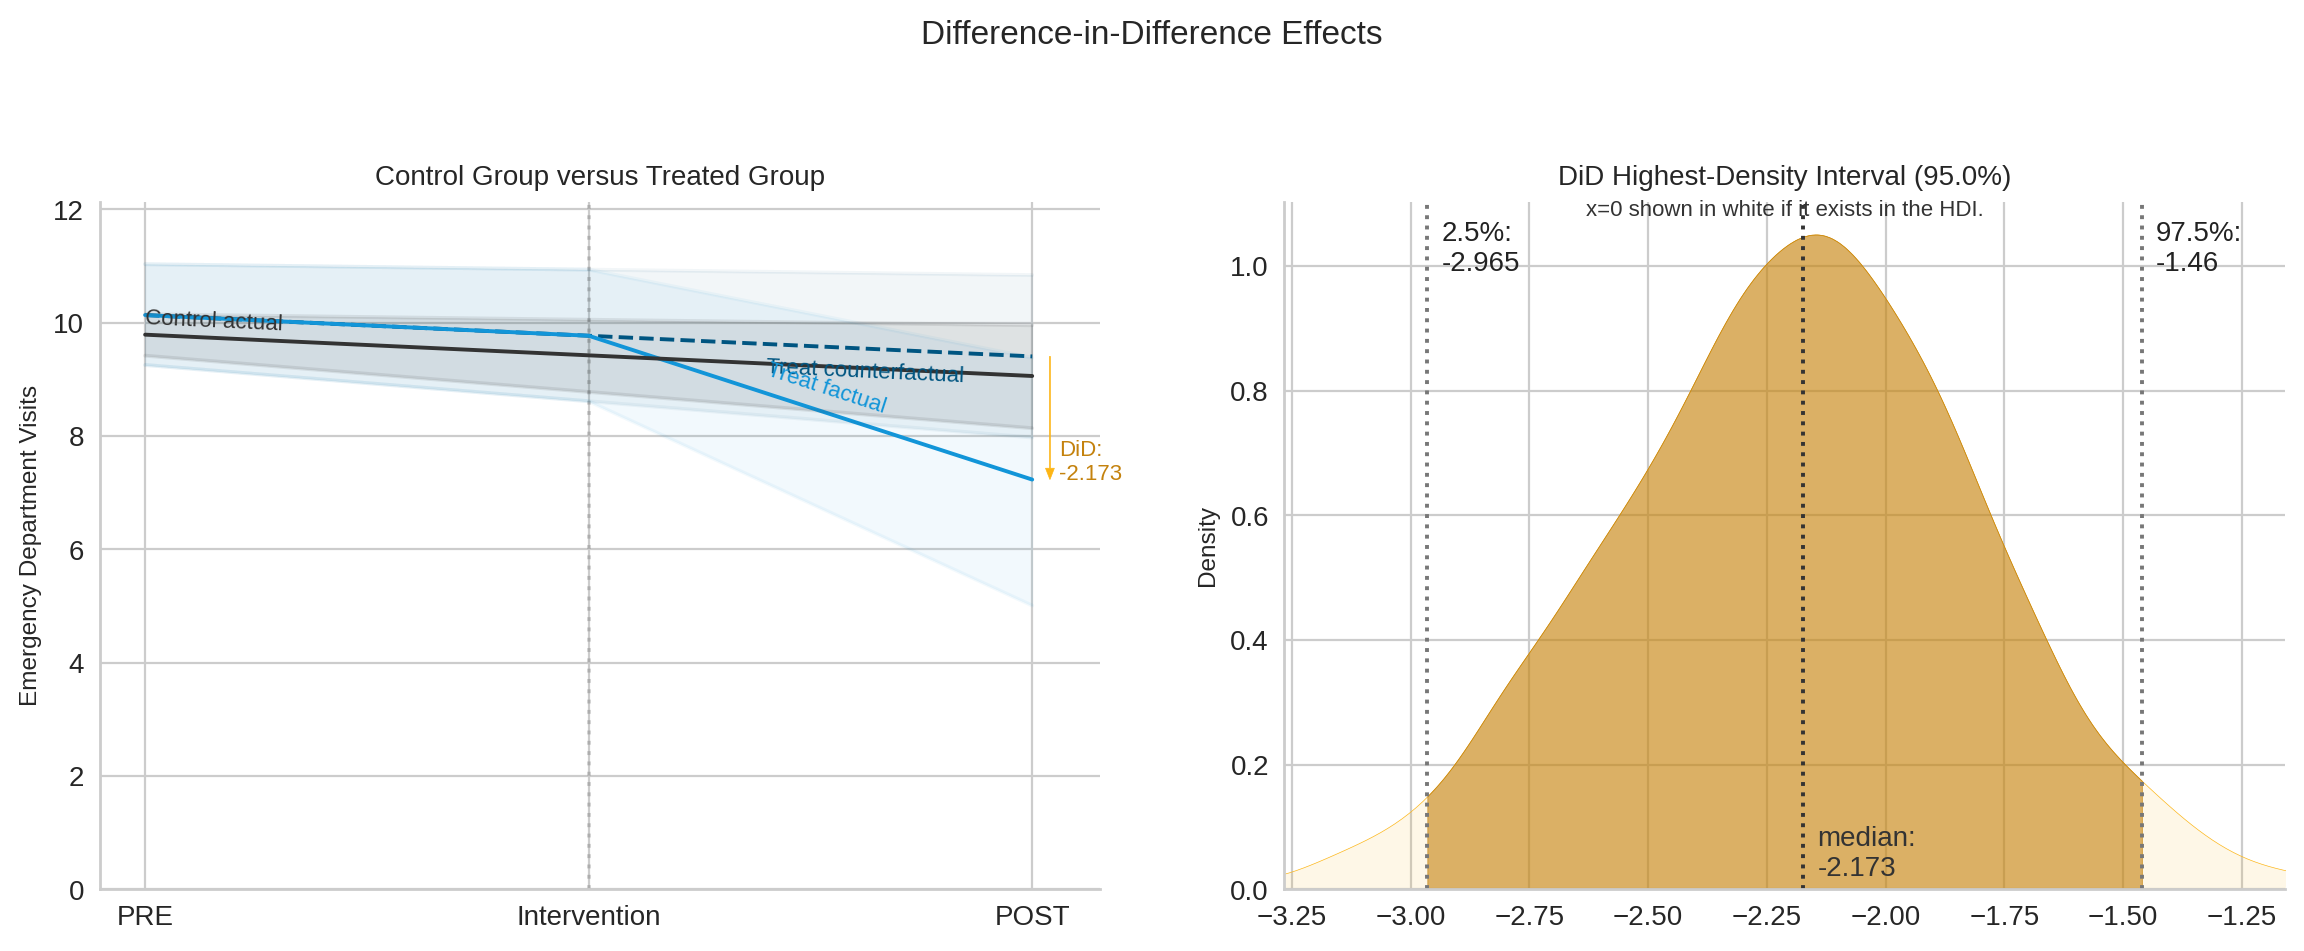

In [6]:
model.plot_effects(model,
                   line_type='single',
                   split_point=0.5,
                   figsize=(12,5),
                   hdi=0.95,
                   suptitle_fontsize=12,
                   title_fontsize=10,
                   label_fontsize=8,
                   tick_fontsize=10,
                   show_did=True,
                   y_label='Emergency Department Visits',
                   y_pad=(0.2, 0.35, 0.2),
                   labels_above_line=(True, False, True)
                  )

## 5. Get a summary table

Another thing you can do is to get a summary table of fitted parameters from the model (usually classically referred to as "Table 2" of many research papers).  To do this easily, we can use the Arviz package.

In [9]:
import arviz as az

az.summary(model.fitted_model)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,9.790,0.190,9.440,10.134,0.005,0.004,1493.0,1350.0,1.0
POST,-0.734,0.274,-1.234,-0.213,0.008,0.006,1308.0,1010.0,1.0
TREAT,0.353,0.269,-0.122,0.883,0.007,0.005,1377.0,1293.0,1.0
TREAT:POST,-2.190,0.384,-2.898,-1.462,0.011,0.008,1241.0,1297.0,1.0
sigma,1.924,0.068,1.797,2.053,0.002,0.002,1832.0,1340.0,1.0


## 6. (Optional) Matching Control Group Using Nearest Neighbors

Bistro also provides a nearest neighbor matching method to help select a control group that is more comparable to the treatment group on key covariates. Here we demonstrate matching on the 'age' variable. Matching can improve the balance between groups before fitting the DiD model.

After matching, we re-fit the DiD model and visualize the results again.


Output()

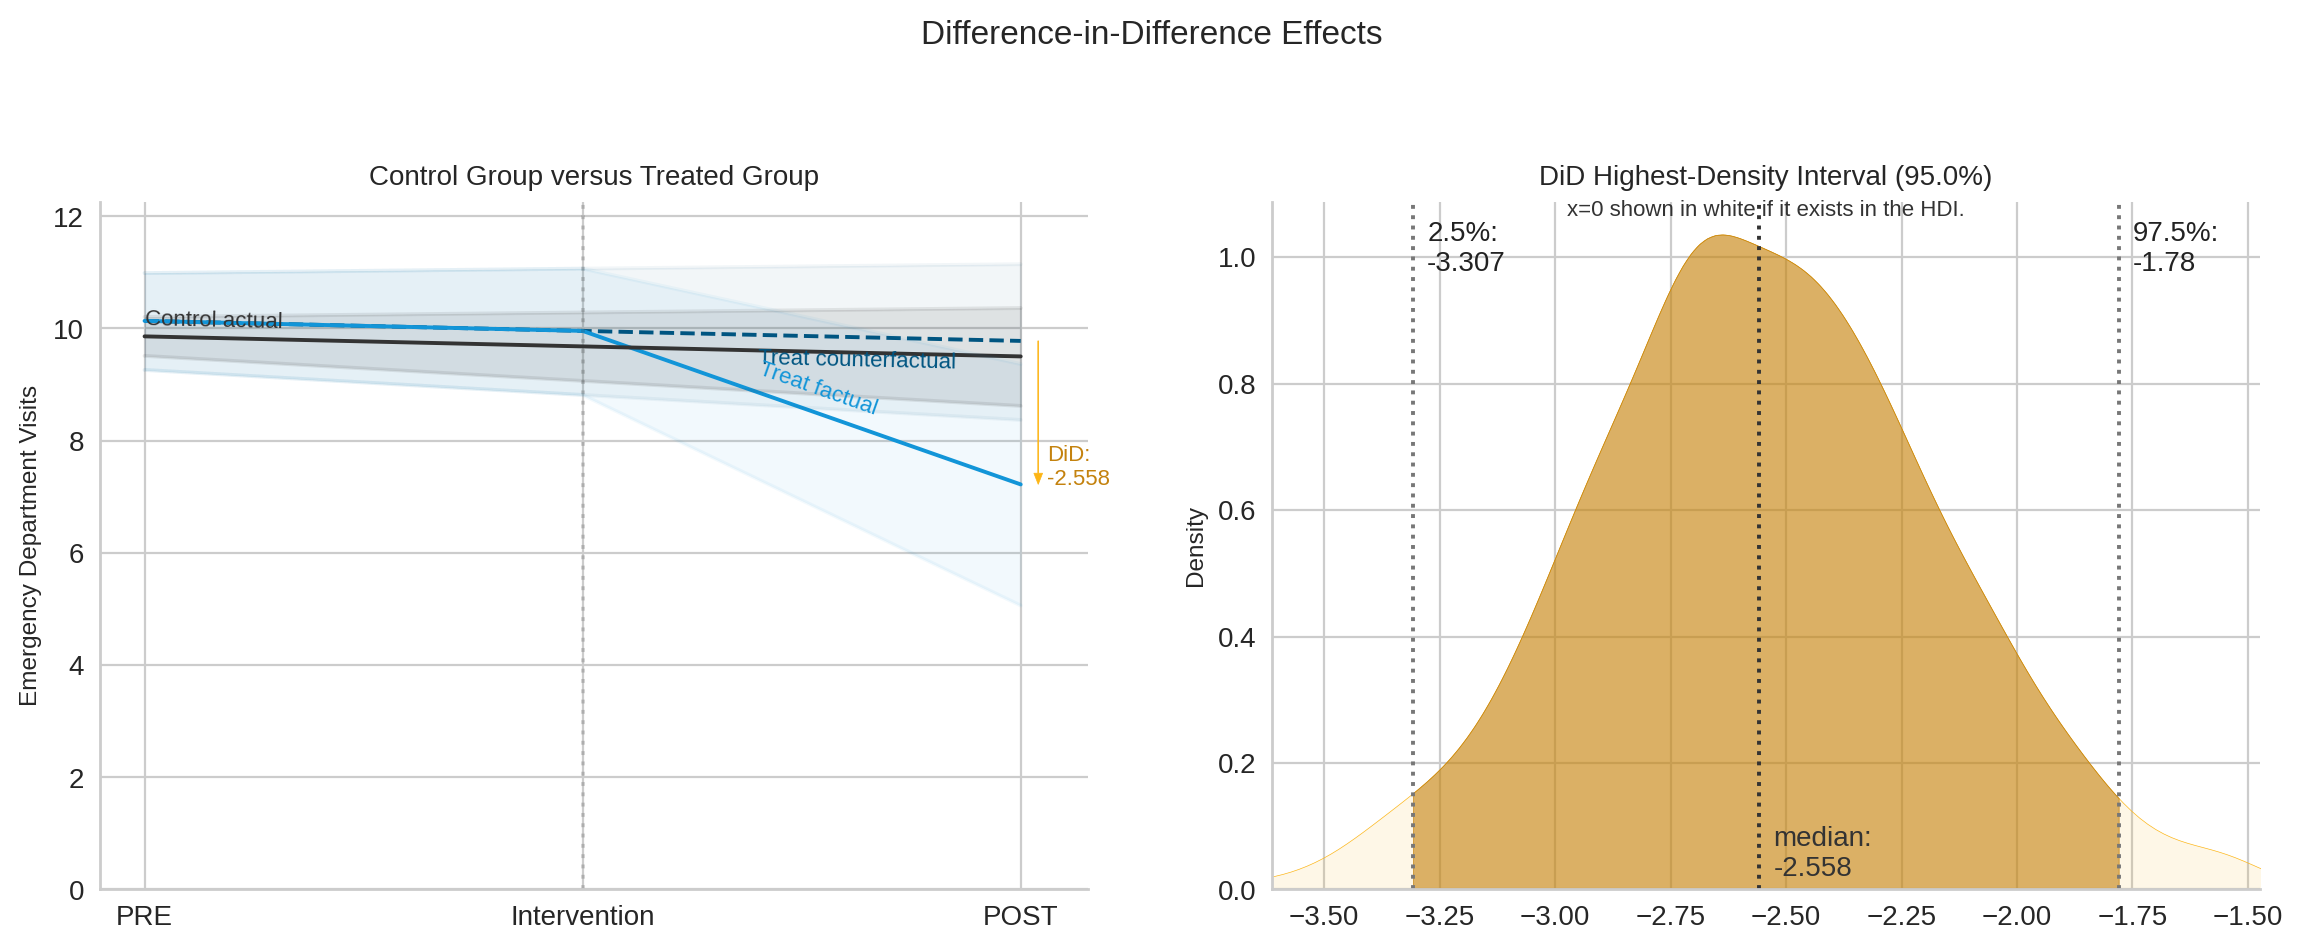

In [10]:
# Apply nearest neighbor matching using the 'age' covariate.
model.match_control_nn(match_features=['age'], neighbors=1, scaling='minmax')

# Re-fit the model using the matched control group
model.fit(reg_formula='Y ~ TREAT + POST + TREAT*POST')

# Plot the DiD effects after matching
model.plot_effects(model,
                   line_type='single',
                   split_point=0.5,
                   figsize=(12,5),
                   hdi=0.95,
                   suptitle_fontsize=12,
                   title_fontsize=10,
                   label_fontsize=8,
                   tick_fontsize=10,
                   show_did=True,
                   y_label='Emergency Department Visits',
                   y_pad=(0.2, 0.35, 0.2),
                   labels_above_line=(True, False, True)
                  )

In [11]:
import arviz as az

az.summary(model.fitted_model)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,9.857,0.176,9.532,10.181,0.004,0.004,1597.0,1568.0,1.0
POST,-0.364,0.268,-0.837,0.174,0.007,0.006,1495.0,1276.0,1.0
TREAT,0.273,0.265,-0.214,0.772,0.007,0.006,1432.0,1556.0,1.0
TREAT:POST,-2.549,0.386,-3.260,-1.808,0.011,0.009,1331.0,1266.0,1.0
sigma,1.887,0.069,1.762,2.014,0.002,0.002,1869.0,1377.0,1.0
